In [1]:
!pip -q install kagglehub vit-pytorch prettytable arrow seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 186.5/186.5 kB 11.6 MB/s eta 0:00:00


In [3]:
!unzip -q /content/brain-tumor-mri-dataset.zip -d /content/data
print("Dataset extracted successfully.")


Dataset extracted successfully.


In [4]:
!find /content/data -maxdepth 3 -type d | sort


/content/data
/content/data/Testing
/content/data/Testing/glioma
/content/data/Testing/meningioma
/content/data/Testing/notumor
/content/data/Testing/pituitary
/content/data/Training
/content/data/Training/glioma
/content/data/Training/meningioma
/content/data/Training/notumor
/content/data/Training/pituitary


In [5]:
import os

def find_folder(root_path, target_name):
    for root, dirs, files in os.walk(root_path):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

TRAIN_DIR = find_folder("/content/data", "Training")
TEST_DIR = find_folder("/content/data", "Testing")

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)

assert TRAIN_DIR is not None, "Training folder not found"
assert TEST_DIR is not None, "Testing folder not found"


TRAIN_DIR: /content/data/Training
TEST_DIR: /content/data/Testing


In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arrow

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix
from tqdm import tqdm
from prettytable import PrettyTable
from PIL import Image

from vit_pytorch import ViT


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [8]:
class TumorClassifierViT(nn.Module):
    def __init__(self, num_classes):
        super(TumorClassifierViT, self).__init__()
        self.vit = ViT(
            image_size=224,
            patch_size=32,
            num_classes=num_classes,
            dim=256,
            depth=4,
            heads=8,
            mlp_dim=512,
            dropout=0.1,
            emb_dropout=0.1
        )

    def forward(self, x):
        return self.vit(x)


In [9]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


In [10]:
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transforms)
val_dataset = ImageFolder(TEST_DIR, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Classes:", train_dataset.classes)
print("Number of training images:", len(train_dataset))
print("Number of testing images:", len(val_dataset))


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5600
Number of testing images: 1600


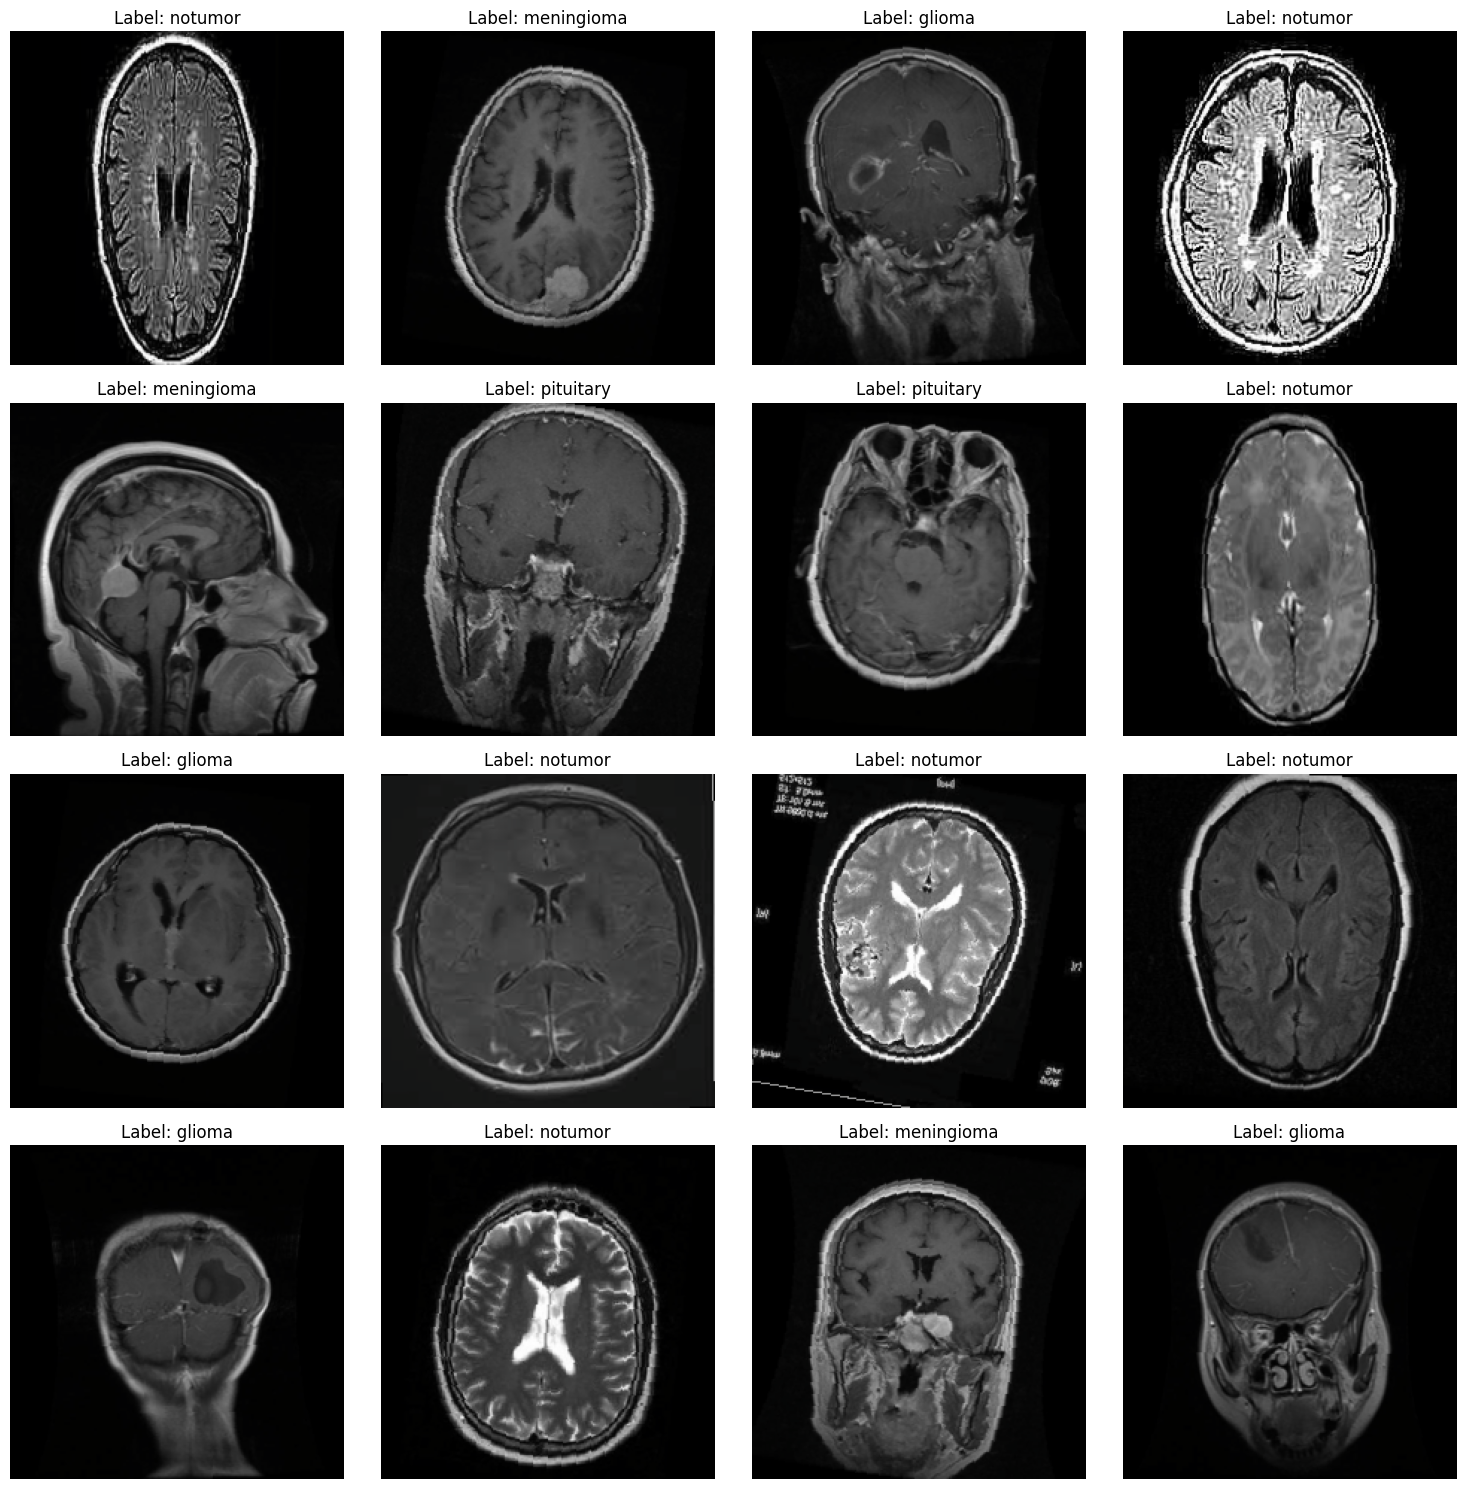

In [11]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

images_np = images.numpy().transpose((0, 2, 3, 1))
images_np = (images_np * std + mean).clip(0, 1)

num_images = min(len(images_np), 16)
rows = int(np.ceil(num_images / 4))

fig, axes = plt.subplots(rows, 4, figsize=(15, 15))
axes = np.array(axes).reshape(-1)

for i, ax in enumerate(axes):
    if i < num_images:
        ax.imshow(images_np[i])
        ax.set_title(f"Label: {train_dataset.classes[labels[i]]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("/content/classes.png")
plt.show()
plt.close()


In [12]:
model = TumorClassifierViT(num_classes=len(train_dataset.classes)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

print(model)


TumorClassifierViT(
  (vit): ViT(
    (to_patch_embedding): Sequential(
      (0): Rearrange('b c (h p1) (w p2) -> b (h w) (p1 p2 c)', p1=32, p2=32)
      (1): LayerNorm((3072,), eps=1e-05, elementwise_affine=True)
      (2): Linear(in_features=3072, out_features=256, bias=True)
      (3): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (transformer): Transformer(
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (layers): ModuleList(
        (0-3): 4 x ModuleList(
          (0): Attention(
            (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
            (attend): Softmax(dim=-1)
            (dropout): Dropout(p=0.1, inplace=False)
            (to_qkv): Linear(in_features=256, out_features=1536, bias=False)
            (to_out): Sequential(
              (0): Linear(in_features=512, out_features=256, bias=True)
              (1): Dropout(p=0.1, inplace=False)
            )
        

In [13]:
num_epochs = 10
best_val_accuracy = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

tableData = PrettyTable([
    "Epoch",
    "Time Elapsed",
    "Train Loss",
    "Train Acc",
    "Val Loss",
    "Val Acc"
])

start_time = arrow.now().timestamp()

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)

            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

    avg_val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_val / total_val

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    elapsed = arrow.get(arrow.now().timestamp() - start_time).format("HH:mm:ss")

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Time: {elapsed} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.2%} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2%}"
    )

    tableData.add_row([
        epoch + 1,
        elapsed,
        f"{avg_train_loss:.4f}",
        f"{train_accuracy:.2%}",
        f"{avg_val_loss:.4f}",
        f"{val_accuracy:.2%}"
    ])

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(model.state_dict(), "/content/best_model.pth")

print("\nBest Validation Accuracy:", f"{best_val_accuracy:.2%}")
print(tableData)


Epoch 1/10: 100%|██████████| 175/175 [00:28<00:00,  6.22it/s]


Epoch [1/10] | Time: 00:00:33 | Train Loss: 1.0433 | Train Acc: 54.20% | Val Loss: 0.9252 | Val Acc: 65.31%


Epoch 2/10: 100%|██████████| 175/175 [00:25<00:00,  6.74it/s]


Epoch [2/10] | Time: 00:01:06 | Train Loss: 0.6655 | Train Acc: 73.61% | Val Loss: 0.9222 | Val Acc: 70.31%


Epoch 3/10: 100%|██████████| 175/175 [00:25<00:00,  6.95it/s]


...

Epoch [8/10] | Time: 00:04:15 | Train Loss: 0.3445 | Train Acc: 87.25% | Val Loss: 0.6792 | Val Acc: 80.25%


Epoch 9/10: 100%|██████████| 175/175 [00:25<00:00,  6.79it/s]


Epoch [9/10] | Time: 00:04:48 | Train Loss: 0.3333 | Train Acc: 87.34% | Val Loss: 0.6865 | Val Acc: 79.31%


Epoch 10/10: 100%|██████████| 175/175 [00:25<00:00,  6.93it/s]


Epoch [10/10] | Time: 00:05:19 | Train Loss: 0.3247 | Train Acc: 87.73% | Val Loss: 0.6285 | Val Acc: 81.62%

Best Validation Accuracy: 81.62%
+-------+--------------+------------+-----------+----------+---------+
| Epoch | Time Elapsed | Train Loss | Train Acc | Val Loss | Val Acc |
+-------+--------------+------------+-----------+----------+---------+
|   1   |   00:00:33   |   1.0433   |   54.20%  |  0.9252  |  65.31% |
|   2   |   00:01:06   |   0.6655   |   73.61%  |  0.9222  |  70.31% |
|   3   |   00:01:37   |   0.5499   |   78.62%  |  0.9510  |  71.88% |
|   4   |   00:02:10   |   0.4836   |   81.77%  |  0.7611  |  75.50% |
|   5   |   00:02:41   |   0.4214   |   83.91%  |  0.7004  |  77.81% |
|   6   |   00:03:12   |   0.3973   |   85.52%  |  0.6765  |  78.31% |
|   7   |   00:03:44   |   0.3721   |   86.02%  |  0.7908  |  77.19% |
|   8   |   00:04:15   |   0.3445   |   87.25%  |  0.6792  |  80.25% |
|   9   |   00:04:48   |   0.3333   |   87.34%  |  0.6865  |  79.31% |
|   1

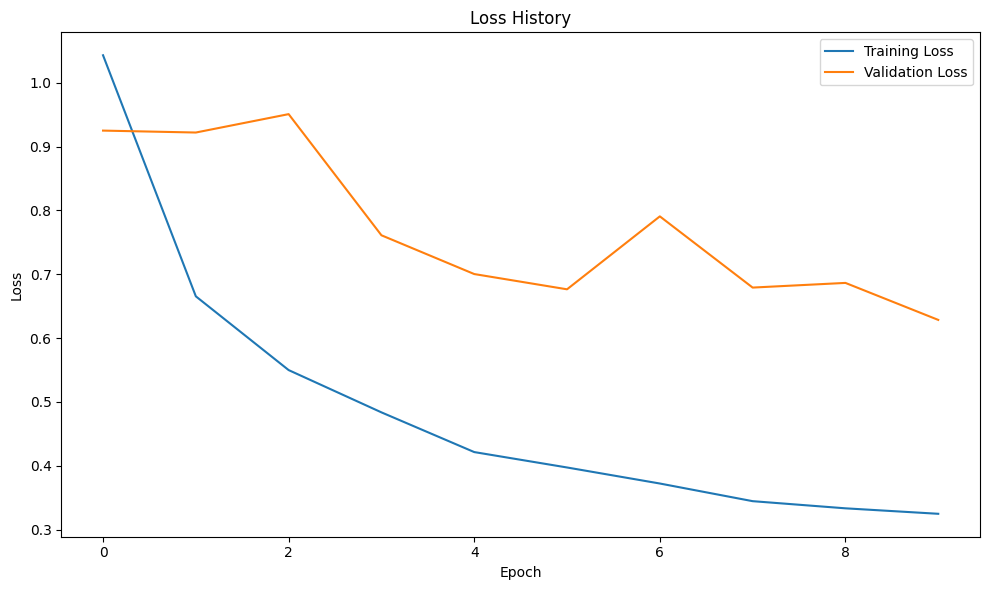

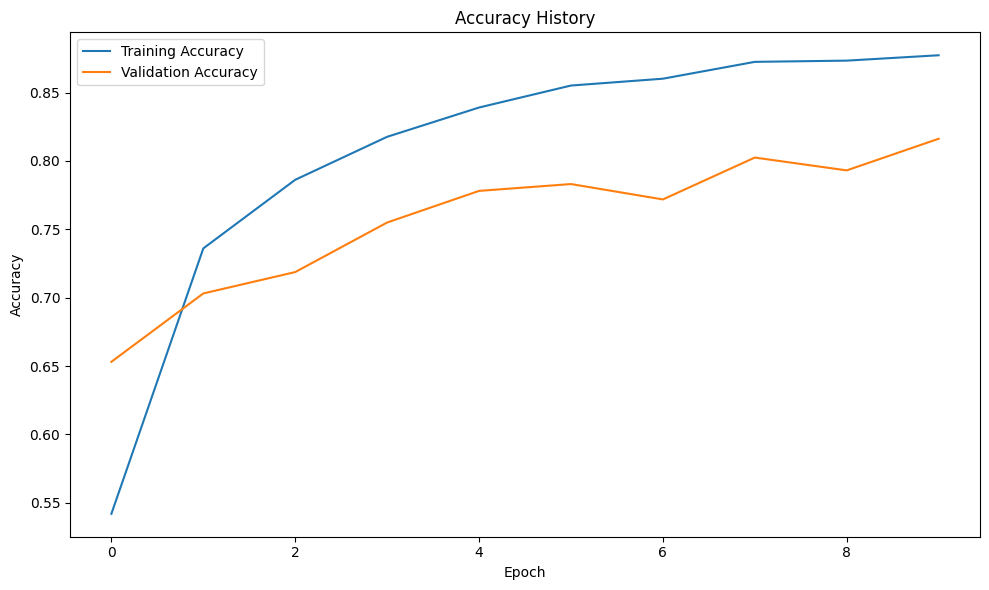

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss History")
plt.legend()
plt.tight_layout()
plt.savefig("/content/loss.png")
plt.show()
plt.close()

plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy History")
plt.legend()
plt.tight_layout()
plt.savefig("/content/accuracy.png")
plt.show()
plt.close()


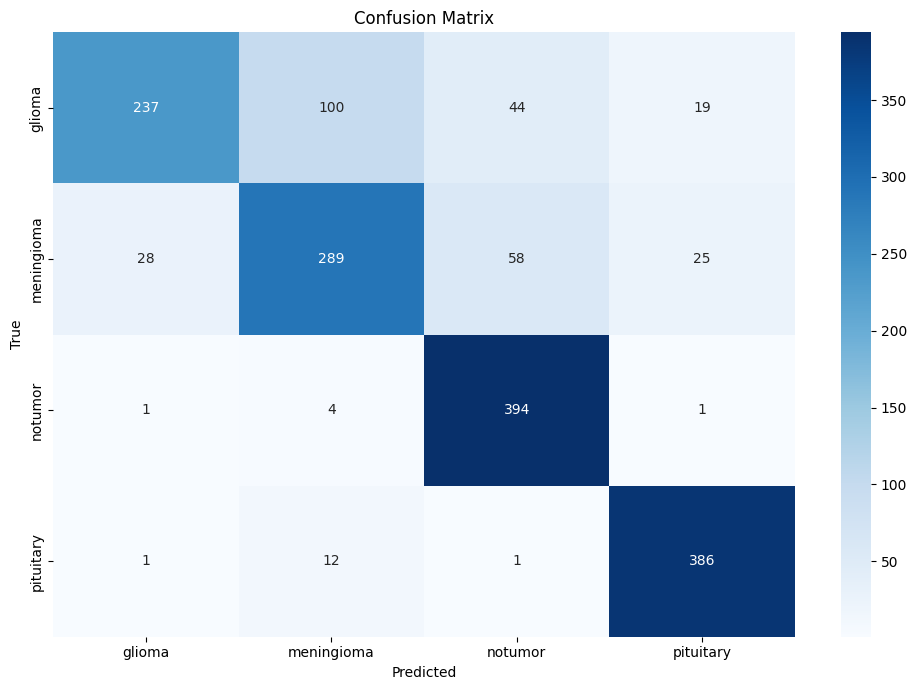

In [15]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 7))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=val_dataset.classes,
    yticklabels=val_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png")
plt.show()
plt.close()


In [16]:
model = TumorClassifierViT(num_classes=len(train_dataset.classes)).to(device)
model.load_state_dict(torch.load("/content/best_model.pth", map_location=device))
model.eval()

class_names = train_dataset.classes
print("Class names:", class_names)


Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
def predict_image(image_path, model, transform, device):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = F.softmax(outputs[0], dim=0)

    confidence, predicted = torch.max(probabilities, 0)
    return predicted.item(), confidence.item(), probabilities.cpu().numpy(), image


In [18]:
sample_class = class_names[0]
sample_class_dir = os.path.join(TEST_DIR, sample_class)
sample_image_path = os.path.join(sample_class_dir, os.listdir(sample_class_dir)[0])

print("Testing image:", sample_image_path)

predicted_class, confidence, probabilities, image = predict_image(
    sample_image_path, model, test_transforms, device
)

print(f"Predicted class: {class_names[predicted_class]}")
print(f"Confidence: {confidence * 100:.2f}%")


Testing image: /content/data/Testing/glioma/Te-gl_235.jpg
Predicted class: glioma
Confidence: 99.83%


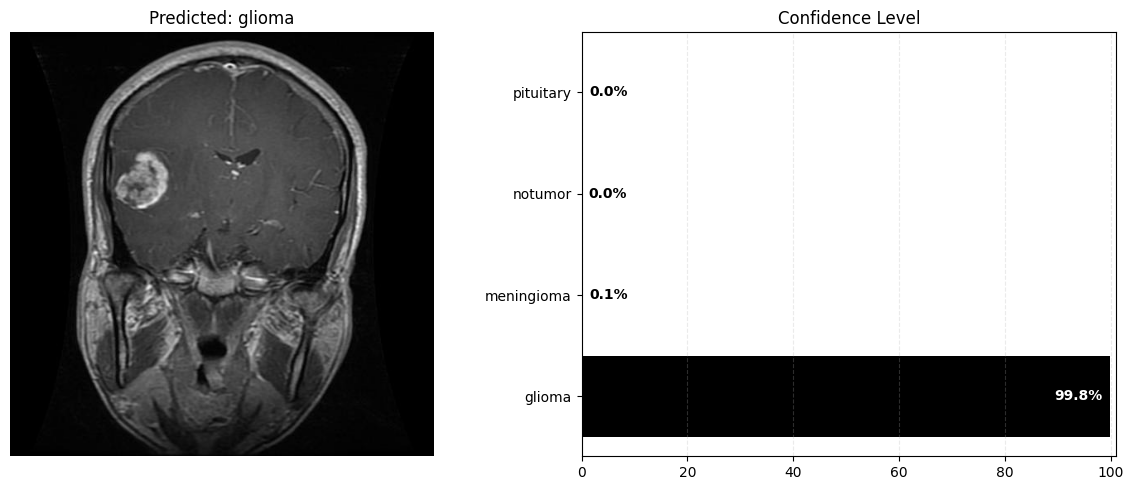

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].imshow(image)
axs[0].set_title(f"Predicted: {class_names[predicted_class]}")
axs[0].axis("off")

probs_percent = probabilities * 100
rects = axs[1].barh(range(len(class_names)), probs_percent, align="center", color="black")
axs[1].set_yticks(range(len(class_names)))
axs[1].set_yticklabels(class_names)
axs[1].set_xlim([0, 101])
axs[1].set_title("Confidence Level")
axs[1].xaxis.grid(True, linestyle="--", alpha=0.25)

for rect in rects:
    width = rect.get_width()
    yloc = rect.get_y() + rect.get_height() / 2
    label_text = f"{width:.1f}%"

    if width < 40:
        xloc = 5
        color = "black"
        ha = "left"
    else:
        xloc = -5
        color = "white"
        ha = "right"

    axs[1].annotate(
        label_text,
        xy=(width, yloc),
        xytext=(xloc, 0),
        textcoords="offset points",
        ha=ha,
        va="center",
        color=color,
        weight="bold"
    )

plt.tight_layout()
plt.savefig("/content/prediction_result.png")
plt.show()
plt.close()


In [20]:
from google.colab import files

files.download("/content/best_model.pth")
files.download("/content/classes.png")
files.download("/content/loss.png")
files.download("/content/accuracy.png")
files.download("/content/confusion_matrix.png")
files.download("/content/prediction_result.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>